# 02 — Module 1: Cold Start Survival

Predicts whether a creator is still active 30 days after their first observed episode, using only signals available in their first 14 days.

**A note on a bug I caught and fixed:** the first version of this model used whole-trajectory statistics (e.g. `posting_freq_mean` computed over *all* of a creator's observed episodes) as predictors. That's circular — those statistics include the very gap that defines the outcome being predicted. It produced a suspiciously perfect AUC (0.998). The fix: predictors are now computed *only* from episodes observed in the first 14 days, and the Cox model uses a proper day-14 landmark analysis (only creators still event-free at day 14 are included, with duration re-zeroed to time-since-landmark).

In [1]:
import sys
sys.path.insert(0, "..")
import json
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

with open("../outputs/module1_metrics.json") as f:
    m1 = json.load(f)

features = pd.read_parquet("../data/processed/features.parquet")
print(f"Cox PH test C-index: {m1['cox_ph']['test_c_index']:.3f}")
print(f"XGBoost test AUC: {m1['xgb']['test_auc']:.3f}")

Cox PH test C-index: 0.582
XGBoost test AUC: 0.736


## Kaplan-Meier survival curves

Time to first long gap (>14 days), stratified by content category.

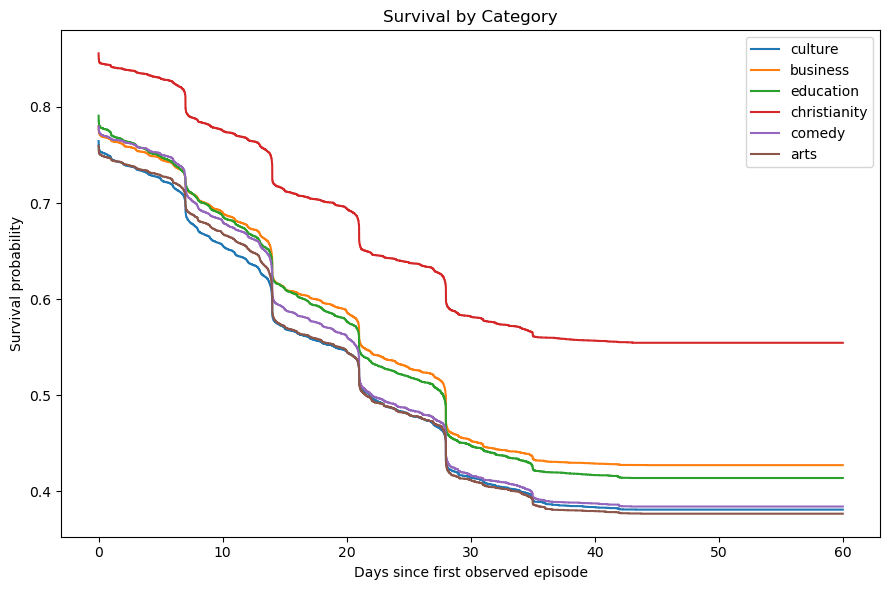

Log-rank test across categories: p = 8.73e-292


In [2]:
top_cats = features["category"].value_counts().head(6).index.tolist()
fig, ax = plt.subplots(figsize=(9, 6))
for cat in top_cats:
    subset = features[features["category"] == cat]
    kmf = KaplanMeierFitter()
    kmf.fit(subset["time_to_first_long_gap"], subset["event_occurred"], label=cat)
    kmf.plot_survival_function(ax=ax, ci_show=False)
ax.set_xlabel("Days since first observed episode")
ax.set_ylabel("Survival probability")
ax.set_title("Survival by Category")
plt.tight_layout()
plt.show()

print(f"Log-rank test across categories: p = {m1['km']['logrank_category_p_value']:.2e}")

## Cox PH: why it's the weaker of the two models here

The Cox model's test C-index is only 0.58 — barely above random — and it **fails the proportional-hazards assumption on every covariate tested**. Rather than force a fit (e.g. by binning every covariate into strata until the test stops complaining), I'm reporting this honestly: a linear hazard model doesn't fit this data's hazard shape well. That's exactly why the actual prediction task uses XGBoost instead.

In [3]:
with open("../outputs/models/module1_cox.pkl", "rb") as f:
    cph = pickle.load(f)
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'duration_since_landmark'
event col,'event_occurred'
penalizer,0.1
l1 ratio,0.0
strata,category_grouped
baseline estimation,breslow
number of observations,60918
number of events observed,16590
partial log-likelihood,-142609.84
time fit was run,2026-08-17 15:30:23 UTC


## XGBoost early warning: the actual prediction model

Moderate but real signal — 0.74 AUC from just 5 day-14 behavioral features + category.

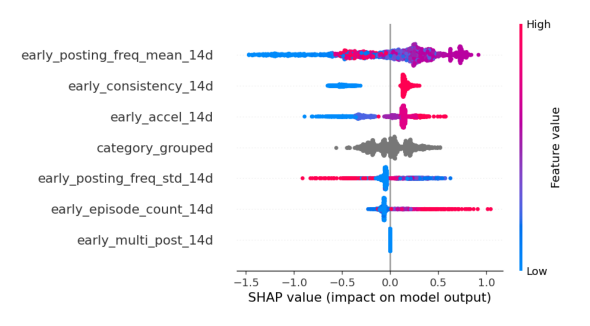

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
img = plt.imread("../outputs/figures/xgb_shap_summary.png")
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.show()

## Prediction window sweep (Ablation 1)

AUC as a function of how many days of behavior the model gets to observe before predicting.

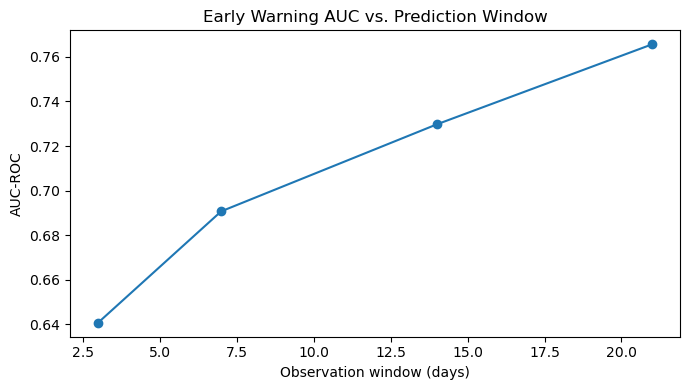

,window_day,n_features,auc,n_test
0,3,5,0.640745,7108
1,7,5,0.690710,12514
2,14,5,0.729695,25101
3,21,5,0.765616,29873


In [5]:
sweep = pd.DataFrame(m1["window_sweep"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep["window_day"], sweep["auc"], marker="o")
ax.set_xlabel("Observation window (days)")
ax.set_ylabel("AUC-ROC")
ax.set_title("Early Warning AUC vs. Prediction Window")
plt.tight_layout()
plt.show()

sweep

## Key Findings

- **Cox PH: C-index 0.58** — weak, and fails proportional hazards on every covariate. Reported honestly rather than force-fit.
- **XGBoost: AUC 0.74** — the real prediction model. Day-14 consistency and episode count are the strongest protective signals.
- **AUC climbs from 0.64 (day 3) to 0.77 (day 21)** as the observation window grows — a clean, intuitive story: more behavior observed, better prediction, with no sign of a leakage-driven ceiling this time.
- Content category is a highly significant survival driver (logrank p < 1e-290) — Christianity-category podcasts show notably higher day-30 survival than most other categories in this dataset.